In [4]:
pip install numpy pandas matplotlib seaborn scikit-learn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.9.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-macosx_10_13_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp313-cp313-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 2.2 MB/s  0:00:04m0:00:0100:01m
Using cached seabor

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


In [9]:
df=pd.read_csv('Country-data.csv')
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [12]:
print(df.shape)
df_copy=df.copy()

(167, 10)


In [13]:
df_copy.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [14]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [ ]:
df_copy.isnull().sum()


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

No Null values

In [17]:
df_copy.duplicated().sum()

np.int64(0)

No Duplicate Values

### Data Cleaning

In [19]:
#stripping whitespaces 
df_copy.columns=df_copy.columns.str.strip()
df_copy

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [21]:
#Removing Duplicates
df_copy=df_copy.drop_duplicates()

In [24]:
#removing the country column since it is a string 
country_names=df_copy['country']
num_features=df_copy.drop("country",axis=1)

In [27]:
#changing all other features into numeric
for col in num_features.columns:
    num_features[col]=pd.to_numeric(num_features[col],errors="coerce")


In [28]:
#Median Imputation to fill missing values
impu=SimpleImputer(strategy="median")
num_features=pd.DataFrame(impu.fit_transform(num_features),columns=num_features.columns)
print(num_features.isnull().sum())

child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


### EDA

In [29]:
df_copy.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


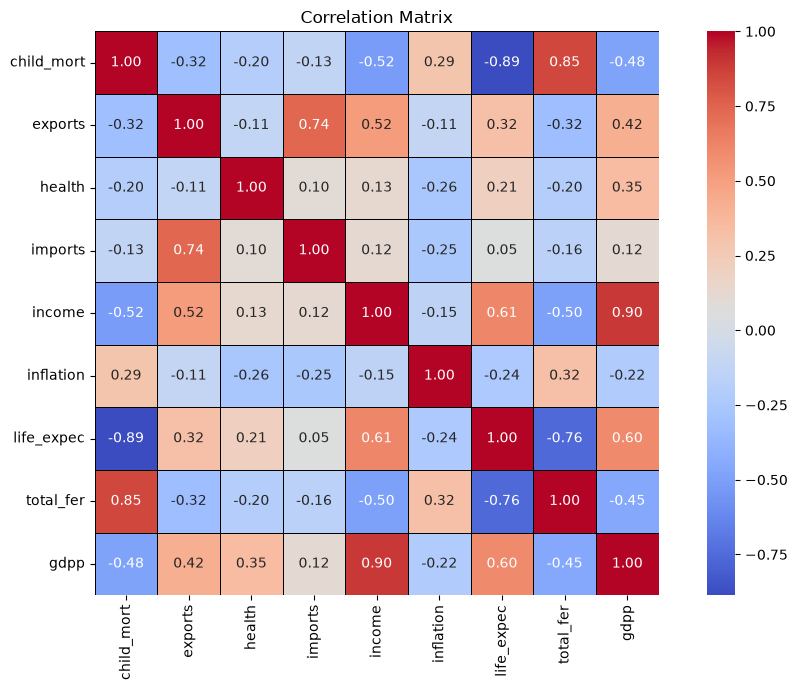

In [31]:
#Correaltion Heatmap
plt.figure(figsize=(10, 7))
corr=num_features.corr()
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',
            linewidths=0.5,linecolor='black',square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Observations:
- Child mortality and life expectancy have strong negative correlation
- Income and gdpp are highly positvely correalated
- Child mortality and fertility rate are strongly positively correlated



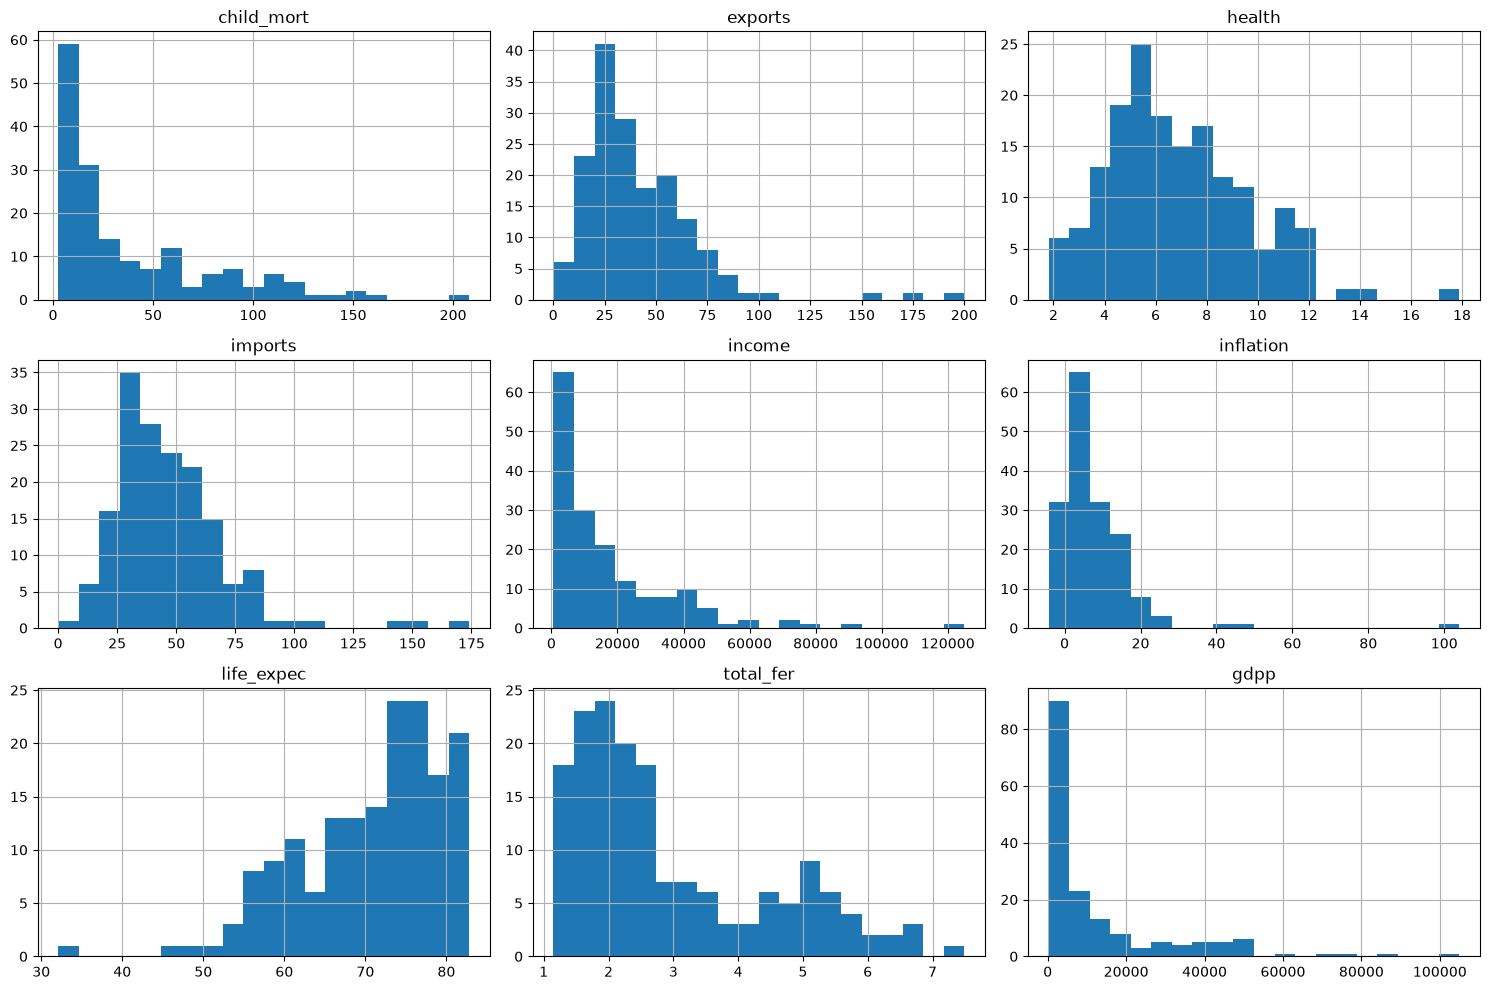

In [33]:
#distribution of numerical features
num_features.hist(
    figsize=(15,10),
    bins=20
)
plt.tight_layout()
plt.show()

Observations
- Income and gdpp are highly right skewed
- Many features are not normally distributed

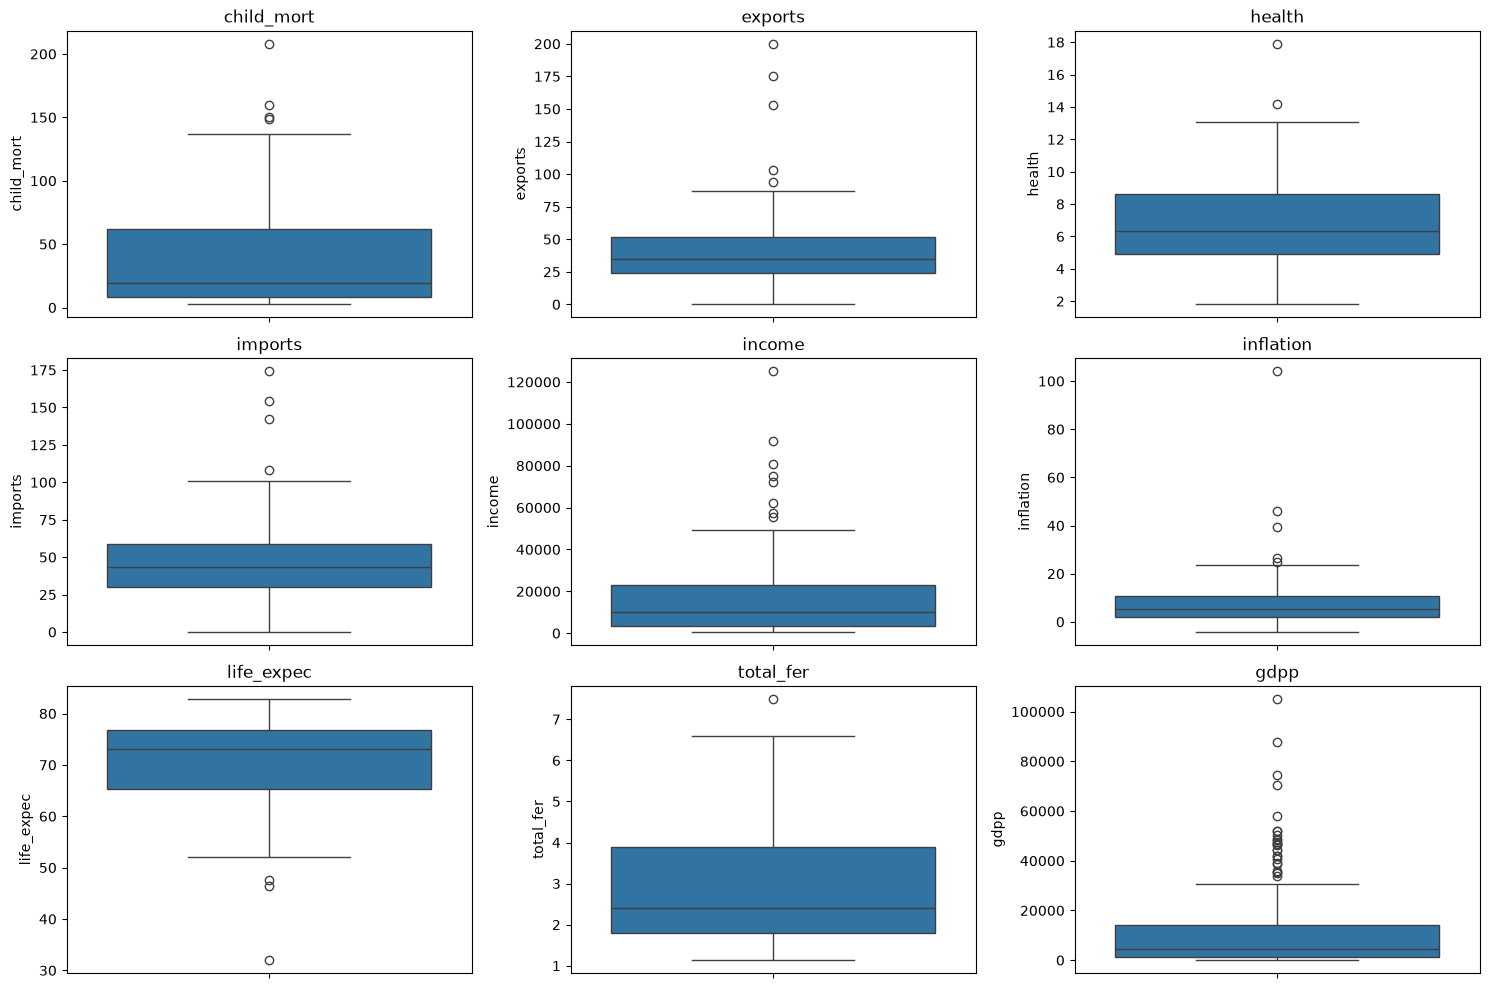

In [34]:
#Outlier Detection
plt.figure(figsize=(15,10))
for i,col in enumerate(num_features,1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df_copy[col])
    plt.title(col)
plt.tight_layout()
plt.show()


Observations
- Severe outliers present in income and gdpp
- infaltion has one big outlier 

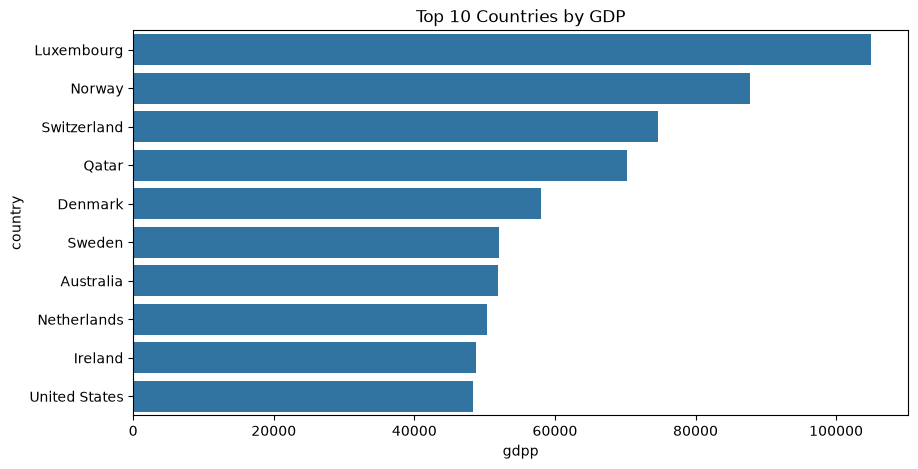

In [35]:
#top 10 countries by gdp
top_gdp=df_copy.sort_values("gdpp",ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x="gdpp",y="country",data=top_gdp)
plt.title("Top 10 Countries by GDP")
plt.show()

### Feature Scaling

In [37]:
scal=StandardScaler()
scal_data=scal.fit_transform(num_features)
scaled_df=pd.DataFrame(scal_data,columns=num_features.columns)
scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


### Elbow Method

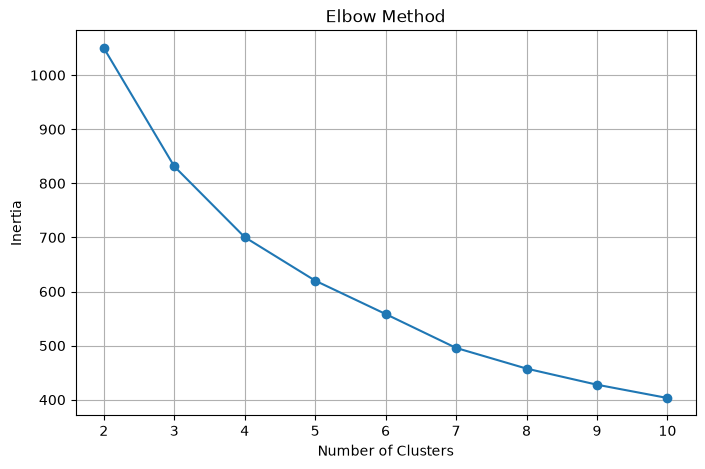

In [40]:
inertias=[]
k_vals=range(2,11)
for k in k_vals:
    kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(scal_data)
    inertias.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(k_vals,inertias,marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

Obseravations:
- Elbow Curve is smooth and has continuous decrease
- This says that data features are higly continuous and corelated


### Training the K-means with the best k_val i.e 3

In [45]:
k=3
kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
kmeans_labels=kmeans.fit_predict(scal_data)
df_copy["Kmeans_cluster"]=kmeans_labels
print(df_copy["Kmeans_cluster"].value_counts())


Kmeans_cluster
2    84
1    47
0    36
Name: count, dtype: int64


### Silhouette Score

In [49]:
ss=silhouette_score(scal_data,kmeans_labels)
print("Silhouette Score of Kmeans:",round(ss,5))

Silhouette Score of Kmeans: 0.2833


Observations:
- based on the score above we can say that we have overlapping boundaries 
- Since the K-means uses Euclidean Distance metric the unhandled outliers in gdpp,income cause the low silhouette score

### Trying DBSCAN

In [48]:
dbscan=DBSCAN(eps=1.5,min_samples=5)
db_labels=dbscan.fit_predict(scal_data)
df_copy["dbscan_cluster"]=db_labels
print(df_copy["dbscan_cluster"].value_counts())


dbscan_cluster
 0    137
-1     30
Name: count, dtype: int64


In [54]:
ss1=silhouette_score(scal_data,db_labels)
print("Silhouette Score for dbscan:",round(ss1,5))

Silhouette Score for dbscan: 0.2883


/var/folders/nf/gntgqb3s1b5c7m5mwkyn32kr0000gn/T/ipykernel_52815/2257735119.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Kmeans_cluster',y='child_mort',data=df_copy,ax=axes[0],palette='Set2')
/var/folders/nf/gntgqb3s1b5c7m5mwkyn32kr0000gn/T/ipykernel_52815/2257735119.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dbscan_cluster',y='child_mort',data=df_copy,ax=axes[1],palette='Set1')


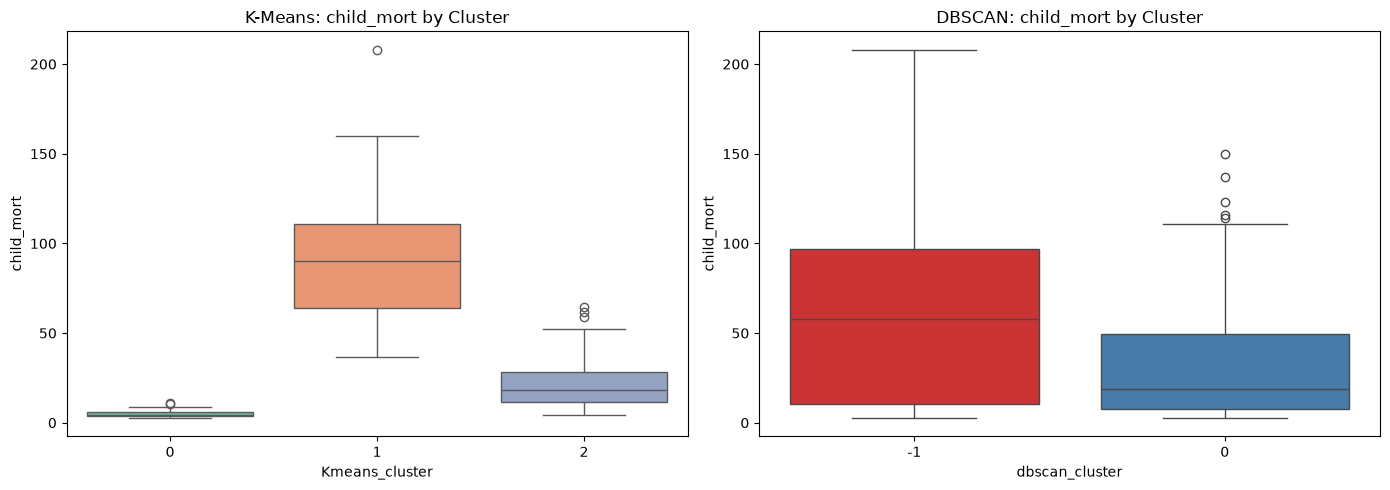

In [56]:
#Comparing the K-Means and DBSCAN cluster profiles
fig,axes = plt.subplots(1,2,figsize=(14, 5))
sns.boxplot(x='Kmeans_cluster',y='child_mort',data=df_copy,ax=axes[0],palette='Set2')
axes[0].set_title('K-Means: child_mort by Cluster')

sns.boxplot(x='dbscan_cluster',y='child_mort',data=df_copy,ax=axes[1],palette='Set1')
axes[1].set_title('DBSCAN: child_mort by Cluster')

plt.tight_layout()
plt.show()

### PCA

In [52]:
pca=PCA(n_components=2)
pca_data=pca.fit_transform(scal_data)
pca_df=pd.DataFrame(pca_data,columns=["pc1","pc2"])
pca_df.head()

,pc1,pc2
0,-2.913025,0.095621
1,0.429911,-0.588156
2,-0.285225,-0.455174
3,-2.932423,1.695555
4,1.033576,0.136659


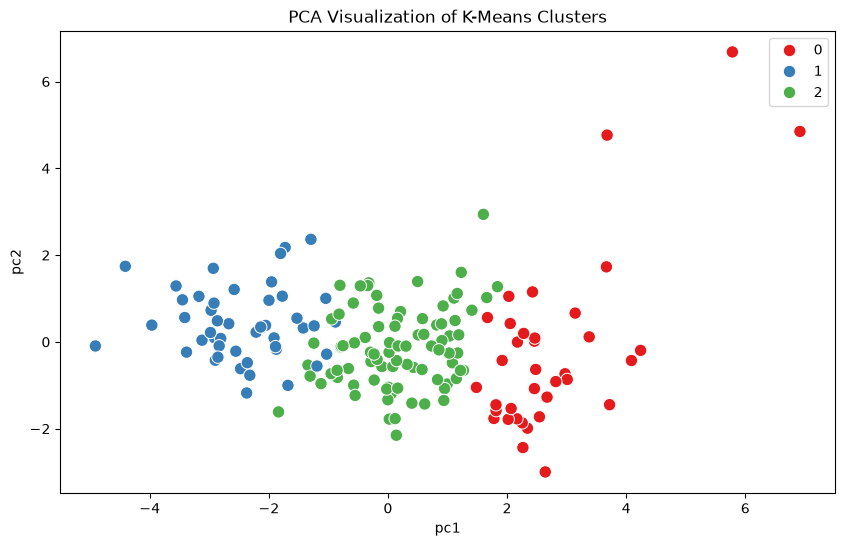

In [53]:
#Scatter plot for pca
plt.figure(figsize=(10,6))
sns.scatterplot(x=pca_df["pc1"],y=pca_df["pc2"],hue=kmeans_labels,palette="Set1",s=80)
plt.title("PCA Visualization of K-Means Clusters")
plt.show()

Observations:
- The groups are having clean boundaries but they are tightly packed against each other
- this explains the low 0.283 silhouette score

### Cluster Profiling

In [59]:
#kmeans
prof=df_copy.groupby('Kmeans_cluster')[num_features.columns].mean().round(2)
prof

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


 Using the cluster profile we can plot the Countries which need help

In [62]:
#the most needy cluster is 1
needy_cluster = 1
countries_need_help = df_copy[df_copy['Kmeans_cluster']==needy_cluster]
countries_need_help[['country','child_mort','income','life_expec','gdpp']].head()

,country,child_mort,income,life_expec,gdpp
0,Afghanistan,90.2,1610,56.2,553
3,Angola,119.0,5900,60.1,3530
17,Benin,111.0,1820,61.8,758
21,Botswana,52.5,13300,57.1,6350
25,Burkina Faso,116.0,1430,57.9,575


/var/folders/nf/gntgqb3s1b5c7m5mwkyn32kr0000gn/T/ipykernel_52815/2073309125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_help,x='child_mort',y='country',palette='Reds_r')


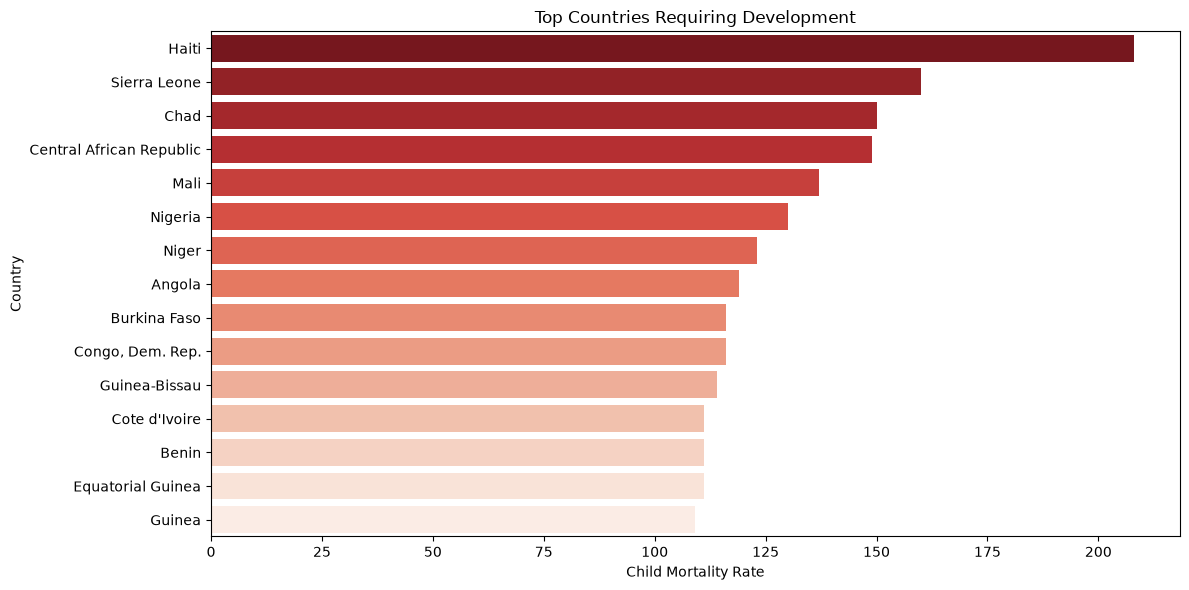

In [63]:
#Plot
top_help=countries_need_help.sort_values(by='child_mort',ascending=False).head(15)
plt.figure(figsize=(12,6))
sns.barplot(data=top_help,x='child_mort',y='country',palette='Reds_r')
plt.title('Top Countries Requiring Development')
plt.xlabel('Child Mortality Rate')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

### Final Insights

- Cluster 1 has the high child Mortality as we see in the Cluster profile of Kmeans it is averaging to 93 deaths per 1000 births

- Cluster 0 has the high income and GDPP which averages 45672 and GDPP averages to 42494 

- So by the above Countries Plot we can say that, The top 10 countries that should be prioritized for aid are
Haiti, Sierra Leone, Chad, Central African Republic, Mali, Nigeria, Niger, Angola, Burkina Faso, and Equatorial Guinea

- Cluster 0 represents Developed Countries
- Countries: Luxembourg, Norway, Switzerland, Qatar, USA, Singapore

- Cluster 1 represents Underdevloped Countries
- Countries:Haiti, Sierra Leone, Chad, Mali, Niger, Burkina Faso
